<a href="https://colab.research.google.com/github/NguyenQuan297/CS4410_Assignment_Troy_2026Spring/blob/main/HomeWork4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Import required libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from sklearn.metrics import confusion_matrix, classification_report


## Loading the dataset

In [2]:
breast_cancer = load_breast_cancer()

X = breast_cancer.data
y = breast_cancer.target

## Checking the Sample and Target Sizes

In [3]:
print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)

Feature matrix shape: (569, 30)
Target vector shape: (569,)


## Splitting the Data for Training and Testing

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=11)

## Training and Testing Set Sizes

In [5]:
print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (426, 30)
Testing set size: (143, 30)


## Creating the Model (GaussianNB)

In [6]:
nb = GaussianNB()

## Training the Model

In [7]:
nb.fit(X_train, y_train)

GaussianNB()

## Predicting

In [8]:
y_pred = nb.predict(X_test)

## Estimator Method score

In [9]:
accuracy = nb.score(X_test, y_test)
print("GaussianNB Accuracy:", accuracy)

GaussianNB Accuracy: 0.951048951048951


## Confusion Matrix

In [10]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[44  6]
 [ 1 92]]


## Classification Report

In [11]:
print("Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=breast_cancer.target_names))

Classification Report:

              precision    recall  f1-score   support

   malignant       0.98      0.88      0.93        50
      benign       0.94      0.99      0.96        93

    accuracy                           0.95       143
   macro avg       0.96      0.93      0.94       143
weighted avg       0.95      0.95      0.95       143



## Visualizing the Confusion Matrix

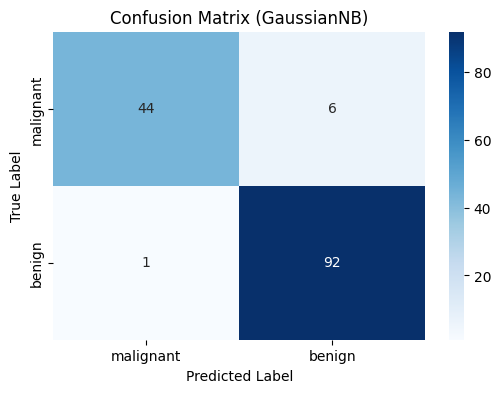

In [12]:
plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=breast_cancer.target_names,
    yticklabels=breast_cancer.target_names
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix (GaussianNB)")
plt.show()

## K-Fold Cross-Validation (10 Folds)

In [13]:
kfold = KFold(n_splits=10, random_state=11, shuffle=True)

scores = cross_val_score(
    estimator=nb,
    X=X,
    y=y,
    cv=kfold
)

print("Cross-validation scores:", scores)
print("Average CV accuracy:", scores.mean())

Cross-validation scores: [0.96491228 0.9122807  0.94736842 0.89473684 0.96491228 0.94736842
 0.96491228 0.89473684 0.96491228 0.92857143]
Average CV accuracy: 0.9384711779448622


## Running Multiple Models to Find the Best One

In [15]:
estimators = {
    'GaussianNB': GaussianNB(),
    'KNeighborsClassifier': KNeighborsClassifier(),
    'LogisticRegression': LogisticRegression(
        solver='lbfgs',
        multi_class='ovr',
        max_iter=10000
    ),
    'SVC': SVC(gamma='scale')
}

In [16]:
for name, estimator in estimators.items():
    scores = cross_val_score(
        estimator=estimator,
        X=X,
        y=y,
        cv=kfold
    )
    print(f"{name} Average Accuracy: {scores.mean():.4f}")

GaussianNB Average Accuracy: 0.9385
KNeighborsClassifier Average Accuracy: 0.9279


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was depre

LogisticRegression Average Accuracy: 0.9508
SVC Average Accuracy: 0.9192
